In [ ]:
!pip install riskfolio-lib
!pip install pyupbit
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.1/985.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 7.6 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import riskfolio as rp
#cvxpy와 pandas를 기반으로 함

import pyupbit

import yfinance as yf

import requests

import pandas as pd

In [ ]:
tickers = pyupbit.get_tickers('KRW')

In [ ]:
#pyupbit.get_ohlcv('KRW-BTC', count = 1592) #2020-05-01 기준 #현재 날짜 기준 count?

In [ ]:
coins_prices = {}

for tick in tickers:
    coin_ohlcv = pyupbit.get_ohlcv(tick, count = 2000)
    daily_price = coin_ohlcv['close']
    coins_prices[tick] = daily_price

In [ ]:
coin_prices_df = pd.DataFrame(coins_prices)

In [ ]:
coin_prices_df.index

DatetimeIndex(['2019-06-18 09:00:00', '2019-06-19 09:00:00',
               '2019-06-20 09:00:00', '2019-06-21 09:00:00',
               '2019-06-22 09:00:00', '2019-06-23 09:00:00',
               '2019-06-24 09:00:00', '2019-06-25 09:00:00',
               '2019-06-26 09:00:00', '2019-06-27 09:00:00',
               ...
               '2024-11-28 09:00:00', '2024-11-29 09:00:00',
               '2024-11-30 09:00:00', '2024-12-01 09:00:00',
               '2024-12-02 09:00:00', '2024-12-03 09:00:00',
               '2024-12-04 09:00:00', '2024-12-05 09:00:00',
               '2024-12-06 09:00:00', '2024-12-07 09:00:00'],
              dtype='datetime64[ns]', length=2000, freq='D')

In [ ]:
coin_prices_df.index = coin_prices_df.index.normalize()

In [ ]:
coin_prices_df.index

In [ ]:
stock_data = yf.download('UTEN', start='2020-01-01')
stock_data = stock_data.dropna()
ten_year = stock_data['Close']

ten_year = pd.DataFrame(ten_year)

ten_year.index.name = None

ten_year.columns = ['UTEN']
ten_year

In [ ]:
coin_prices_df

# Correlation Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
coin_corr_df = coin_prices_df.corr()
coin_corr_df.apply(lambda x: x.nlargest(2).iloc[-1])

,0
KRW-BTC,0.929053
KRW-ETH,0.939319
KRW-NEO,1.000000
KRW-MTL,1.000000
KRW-XRP,0.955113
...,...
KRW-RENDER,0.986521
KRW-MOVE,0.829417
KRW-ME,1.000000
KRW-MOCA,1.000000


In [ ]:
coin_corr_df = coin_prices_df.corr().fillna(0)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a larger figure size for better resolution
figsize = (30, 30)

# Create the clustermap with larger boxes
cluster_map = sns.clustermap(
    coin_corr_df,
    annot=True,
    cmap='coolwarm',
    figsize=figsize,  # Use the defined figsize
    annot_kws={"size": 4},  # Adjust the font size of annotations
    fmt='.2f',  # Format annotations to 2 decimal places
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.05, 0.05),  # Reduce the size of dendrograms
    tree_kws=dict(linewidths=1.5)  # Increase dendrogram line width
)

# Remove the colorbar by setting its label to an empty string and hiding it
cluster_map.cax.set_visible(False)

# Adjust font size for tick labels
plt.setp(cluster_map.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(cluster_map.ax_heatmap.get_yticklabels(), fontsize=8)

# Save the figure with high resolution
cluster_map.savefig("/content/clustermap_high_resolution.png", dpi=300)

# Display the plot
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Extract the linkage matrix
linkage_matrix = cluster_map.dendrogram_row.linkage

# Get cluster labels by cutting the dendrogram at a higher level
max_d = 1.5  # Adjust this value to cut the dendrogram at a higher level 1~2
clusters = fcluster(linkage_matrix, max_d, criterion='distance')

# Print the group of assets in each cluster
from collections import defaultdict

cluster_dict = defaultdict(list)
for asset, cluster in zip(coin_corr_df.index, clusters):
    cluster_dict[cluster].append(asset)

for cluster, assets in cluster_dict.items():
    print(f"Cluster {cluster}: {assets}")

Cluster 29: ['KRW-BTC', 'KRW-BCH', 'KRW-SOL']
Cluster 30: ['KRW-ETH', 'KRW-DOGE', 'KRW-SHIB']
Cluster 28: ['KRW-NEO', 'KRW-ONT', 'KRW-ANKR', 'KRW-T']
Cluster 6: ['KRW-MTL', 'KRW-WAVES', 'KRW-XEM', 'KRW-STEEM', 'KRW-ARDR', 'KRW-IOST', 'KRW-UPP', 'KRW-QKC', 'KRW-MOC', 'KRW-GAME2', 'KRW-MED', 'KRW-BORA', 'KRW-JST', 'KRW-HUNT']
Cluster 12: ['KRW-XRP']
Cluster 23: ['KRW-ETC', 'KRW-CHZ', 'KRW-GRT']
Cluster 4: ['KRW-SNT', 'KRW-XLM', 'KRW-GRS', 'KRW-ICX', 'KRW-TT', 'KRW-MBL', 'KRW-MLK', 'KRW-STPT', 'KRW-STMX', 'KRW-HIVE', 'KRW-AHT', 'KRW-TON', 'KRW-AQT', 'KRW-META', 'KRW-CBK', 'KRW-HPO']
Cluster 24: ['KRW-QTUM', 'KRW-BTG', 'KRW-THETA', 'KRW-CRO', 'KRW-XEC']
Cluster 22: ['KRW-LSK', 'KRW-CVC', 'KRW-GLM', 'KRW-PUNDIX']
Cluster 35: ['KRW-ARK', 'KRW-SBD']
Cluster 36: ['KRW-STORJ', 'KRW-LOOM']
Cluster 11: ['KRW-ADA', 'KRW-IOTA', 'KRW-KNC', 'KRW-ATOM', 'KRW-KAVA', 'KRW-MATIC']
Cluster 40: ['KRW-POWR']
Cluster 7: ['KRW-EOS', 'KRW-XTZ', 'KRW-1INCH', 'KRW-ALGO', 'KRW-CELO', 'KRW-APT']
Cluster 33: ['KRW-

# Interpretation

While we are certian that liquidity is the crucial drive of cryptocurrency market, there is always variations between different coins, and some may even be correlated and indiciate new characteristics and relationships.

The correlation clustering was implemented on 200 days.

Cluster 29 indicates traditional correlations between BTC and BCH

Cluster 30 demonstrates the role as a representative of altcoins seemed to be have been implied in Ethereum and Doge
- Shiba seemed to have been driven by the correlation with Doge
- Need to note that these 3 coins are iconic for their high trading volumes

The concept of "Themes" were implied within this correlation matrix. For example, Neo and Ontology in cluster 28 are iconic CHINESE coins.

Cluster 36: blockchain based infrastructure, storage and scalable Dapps

Cluster 11: ADA, MIOTA, Polygon are Defi projects.

Cluster 23: CHZ and GRT both ERC-20 coins

etc

The correlation matrix also seemed to reflect partnerships for certain coins, like Neo and Ontology which are also represents Chinese markets

# Summary)

correlation may reflect themes, similar market transaction pattern, partnership or more hidden relationships regarding the characteristic of the coins. May be attracting similar investor demographics based on their interests.

# Improvement)

Based on personal experience, the writer has personally observed the correlations and themes existing within 'smaller' timeframes.

For example, 3 AI theme coins such as FET, AGIX, and OCEAN has announced it's merge, leading to significant surg.

Few days before the Hongkong ETF approval, China theme coins such as Neo, Ontology, and VET all experienced counter-trend surge while the overall market was blue due to the anticipation towards China crypto investment.

Clearly, there exists minor trends and linkage by the interaction of market issues that people can interpret, leading to the prossibility of sentimental analysis or short term trend reading model.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Adjust the figure size for better resolution
plt.figure(figsize=(30, 30))

# Create the clustermap
cluster_map = sns.clustermap(coin_corr_df, annot=True, cmap='coolwarm', figsize=(30, 30))

# Save the figure with high resolution
cluster_map.savefig("clustermap.png", dpi=300)

plt.show()

NameError: name 'coin_corr_df' is not defined

<Figure size 3000x3000 with 0 Axes>

ValueError: The condensed distance matrix must contain only finite values.

<Figure size 1500x1200 with 0 Axes>

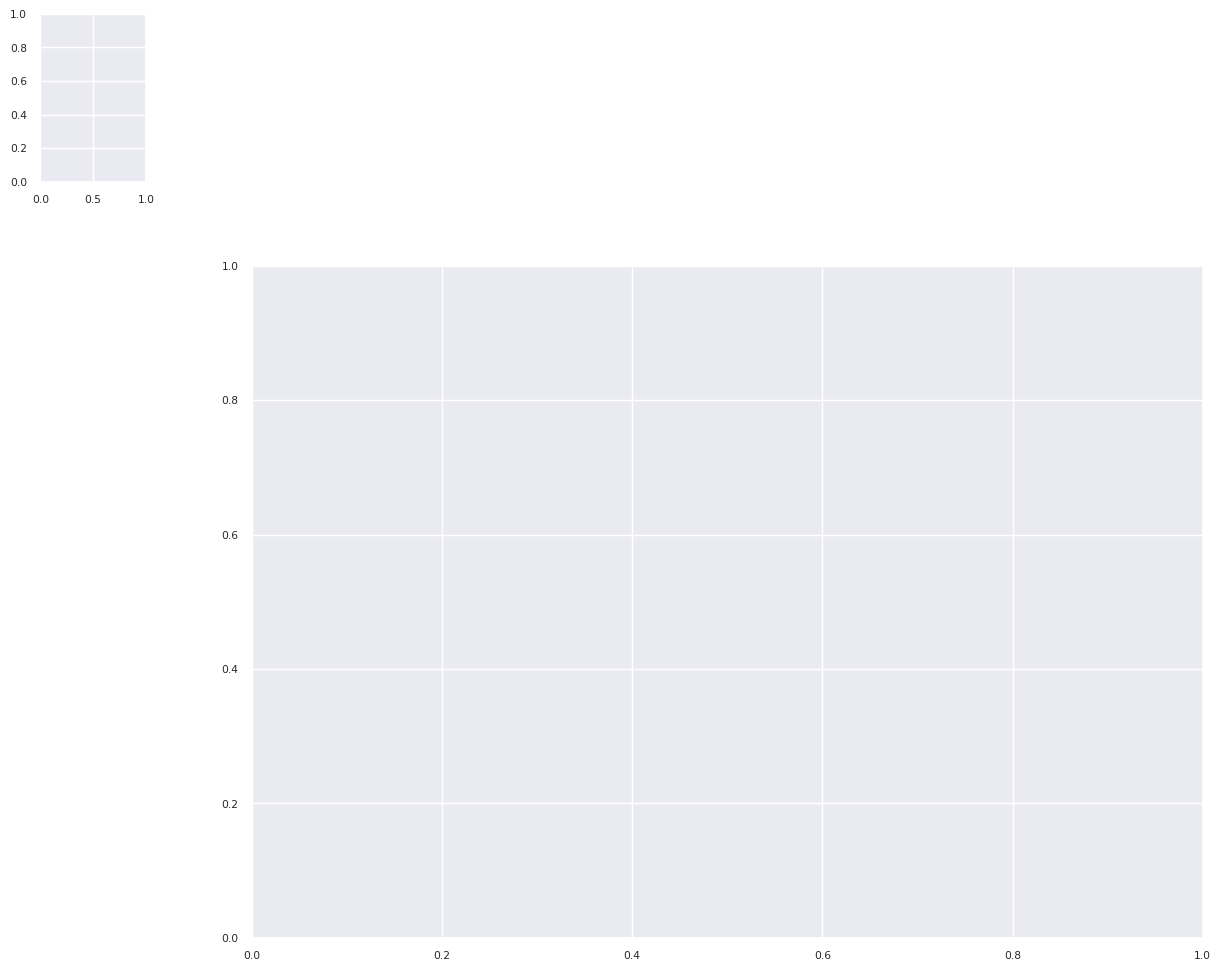

In [ ]:
sns.set(font_scale=0.7)  # Adjust font scale for readability
plt.figure(figsize=(15, 12))  # Increase figure size

cluster_map = sns.clustermap(coin_corr_,
                             method='average',
                             metric='euclidean',
                             cmap='RdYlBu_r',
                             annot=True,  # Display the values
                             figsize=(15, 12),
                             dendrogram_ratio=(.1, .2),
                             cbar_pos=(0, .2, .03, .4),
                             tree_kws={'linewidths': 1.5})

# Adjust labels if needed
plt.setp(cluster_map.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(cluster_map.ax_heatmap.get_yticklabels(), rotation=0)

# Show the plot
plt.show()

In [ ]:
coins_and_10_year = pd.merge(coin_prices_df, ten_year,left_index=True, right_index=True)
coins_and_10_year

In [ ]:
coins_and_10_year.isna().sum()

In [ ]:
old_coins = coins_and_10_year.dropna(axis=1) # 120 코인, 113개 코인 200일 치

In [ ]:
returns = old_coins[old_coins.columns].pct_change().dropna()

In [ ]:
returns

# Create Portfolio

In [ ]:
port = rp.Portfolio(returns=returns)

#rp는 업비트에도 적용가능하다!

port
#그냥 riskfolio 객체로 저장되어있다

In [ ]:
#과거 데이터를 기반으로 분포를 생성
method_mu = "hist" #평균
method_cov = "hist" #공분산

In [ ]:
# 포트폴리오를 해당 분포로 업데이트
port.assets_stats(method_mu=method_mu, method_cov=method_cov, d=0.94)

#type signature, api documentation 확인 가능

In [ ]:
# Run the optimization with a minimum return using the classicial
# mean-variance optimization framework
w = port.rp_optimization(
    model="Classic",
    rm="MV",
    hist=True,
    rf=0.05,
    b=None
)

#평균 분산 최적화 설명 https://wikidocs.net/91509
#정규분포(즉, 가우스 분포)로 랜덤한 수익률의 분포를 연속적이라고 가정하고 최적화(중심극한정리가 전)
#주가와 달리 정상성을 갖기에 시계열 분석을 하기에도 용이하다

#직관적으로 볼때, 무위험자산이 포함된다면 최적의 투자 포트폴리오는
#무위험자산과 efficient frontier에 접하는 점이 이루는 직선상에 존재하게 된다.
#"One Fund Theorem"

In [ ]:
# Plot the risk contributions of each ETF which as we can see is
# equal.
ax = rp.plot_risk_con(
    w,
    cov=port.cov,
    returns=port.returns,
    rm="MV",
    rf=0.05
)

#동일 위험을 감당하도록 asset별 비율 조정이 자동으로 된다

In [ ]:
ax = rp.plot_pie(w=w)
#해당 asset들의 비중

In [ ]:
port_val = 10_000
w["invest_amt"] = w * port_val
w["last_price"] = old_coins.iloc[-1]
w["shares"] = (w.invest_amt / w.last_price).astype(int)
(w["shares"] * w["last_price"]).sum()

In [ ]:
w['weights'].sort_values(ascending=False)

# Sharpe Ratio

In [ ]:
import pandas as pd

# Assuming coin_prices_df is already loaded with your data
# Calculate daily returns for each coin
daily_returns = coin_prices_df.pct_change()

# Define the risk-free rate (set to 0 for simplicity if unknown)
risk_free_rate = 0

# Calculate the Sharpe Ratio for each coin and sort from highest to lowest
sharpe_ratios = ((daily_returns.mean() - risk_free_rate) / daily_returns.std()).sort_values(ascending=False)

# Display the sorted Sharpe Ratios
print("Sharpe Ratios for each coin (sorted from highest to lowest):")
pd.set_option('display.max_rows', 200)
display(sharpe_ratios)

Sharpe Ratios for each coin (sorted from highest to lowest):


,0
KRW-UNI,0.232567
KRW-UXLINK,0.203245
KRW-PENDLE,0.145107
KRW-BIGTIME,0.131990
KRW-INJ,0.129321
KRW-PEPE,0.106266
KRW-ZRO,0.089355
KRW-USDC,0.085161
KRW-ONDO,0.077742
KRW-ENS,0.075486
